# Mobilidade e Efeito Doppler

Este notebook explica diferentes maneiras pelas quais os efeitos da mobilidade podem ser simulados usando o [módulo de ray tracing (RT) do Sionna](https://nvlabs.github.io/sionna/rt/index.html). Você irá:

* Usar as propriedades `position` e `orientation` para mover os objetos da cena;
* Compreender a propriedade `velocity` dos objetos da cena e seu impacto no deslocamento Doppler;
* Aprender a usar a propriedade `doppler` de um objeto `Paths` para simular a evolução temporal dos canais.

## Informações básicas

Existem duas maneiras pelas quais podemos simular o impacto do movimento dos objetos da cena na resposta ao impulso do canal. A primeira consiste em mover os objetos desejados em pequenos passos ao longo de uma trajetória e recalcular os caminhos de propagação a cada passo. Embora essa abordagem seja a mais precisa, ela tem como custo uma alta complexidade computacional. Como veremos mais adiante neste notebook, felizmente essa abordagem não é necessária quando os comprimentos das trajetórias consideradas são pequenos, ou seja, não maiores do que alguns comprimentos de onda. Nesse caso, podemos calcular a evolução temporal da resposta ao impulso do canal usando a segunda abordagem, que se baseia nos deslocamentos Doppler experimentados por todos os caminhos de propagação. Ela é muito rápida e, em muitos casos, produz previsões bastante precisas.

Para calcular o deslocamento Doppler de um caminho específico, conforme mostrado na figura abaixo, o Sionna RT utiliza os [vetores de velocidade](https://nvlabs.github.io/sionna/rt/api/scene_object.html#sionna.rt.SceneObject.velocity) dos objetos da cena.

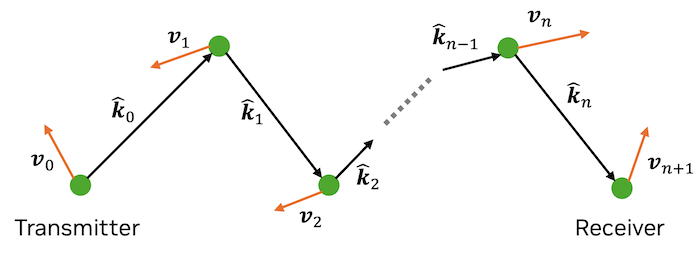

Durante o percurso do transmissor até o receptor, o caminho passa por $n$ processos de espalhamento, como reflexão, refração, espalhamento difuso ou difração. O objeto sobre o qual está localizado o $i$-ésimo ponto de espalhamento possui o vetor de velocidade $\mathbf{v}_i$, e a direção do raio que sai desse ponto é representada por $\hat{\mathbf{k}}_i$. O primeiro e o último ponto correspondem ao transmissor e ao receptor, respectivamente.

O deslocamento Doppler $f_\Delta$ para esse caminho pode ser calculado como (consulte a [documentação](https://nvlabs.github.io/sionna/rt/api/paths.html#sionna.rt.Paths.doppler) de `Paths.doppler`):

$$
f_\Delta = \frac{1}{\lambda}\left[\mathbf{v}_{0}^\mathsf{T}\hat{\mathbf{k}}_0 - \mathbf{v}_{n+1}^\mathsf{T}\hat{\mathbf{k}}_n + \sum_{i=1}^n \mathbf{v}_{i}^\mathsf{T}\left(\hat{\mathbf{k}}_i-\hat{\mathbf{k}}_{i-1} \right) \right] \qquad \text{[Hz]}
$$

onde $\lambda$ é o comprimento de onda. O deslocamento Doppler pode então ser usado para calcular a evolução temporal do coeficiente do caminho `Paths.a`:

$$
a(t) = a e^{j2\pi f_\Delta t}.
$$

## Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Import or install Sionna
try:
    import sionna.rt
except ImportError as e:
    # Only auto-install when the package itself is missing, not when a
    # transitive dependency fails to import.
    if getattr(e, "name", None) not in ("sionna", "sionna.rt"):
        raise
    import os
    import sys
    if "google.colab" in sys.modules:
        # Install Sionna RT in Google Colab
        print("Installing Sionna RT and restarting the runtime. Please run the cell again.")
        os.system("pip install sionna-rt")
        os.kill(os.getpid(), 5)
    else:
        raise e

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      RadioMapSolver, PathSolver
from sionna.rt.utils import r_hat, subcarrier_frequencies

## Controlando a posição e a orientação dos objetos da cena

Todo objeto em uma cena possui as propriedades `position` e `orientation`, que podem ser consultadas e modificadas.

Para visualizar isso, vamos carregar uma cena composta por um simples cânion urbano (street canyon) e alguns carros.

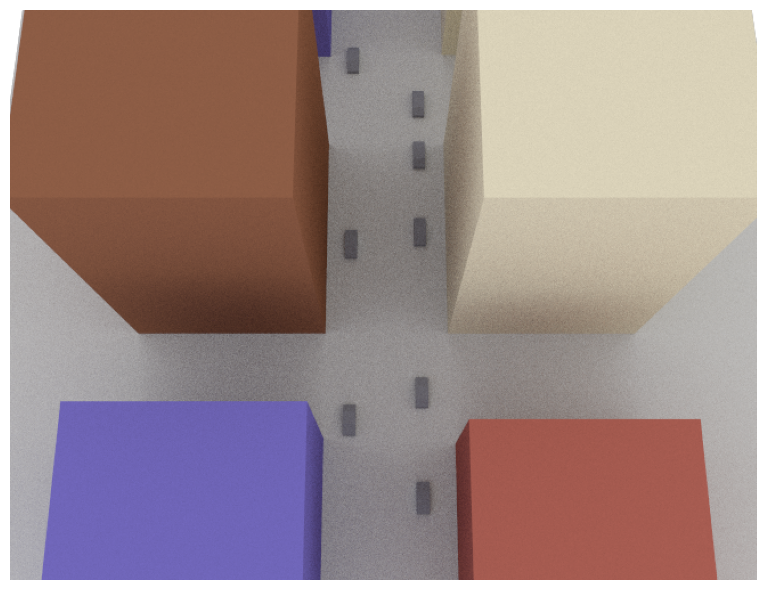

In [2]:
scene = load_scene(sionna.rt.scene.simple_street_canyon_with_cars,
                   merge_shapes=False)
cam = Camera(position=[50,0,130], look_at=[10,0,0])

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

A lista com todos os objetos na cesa pode ser vista da seguinte forma:

In [3]:
scene.objects

{'building_1': <sionna.rt.scene_object.SceneObject at 0x741019175e50>,
 'building_6': <sionna.rt.scene_object.SceneObject at 0x7410191772f0>,
 'building_5': <sionna.rt.scene_object.SceneObject at 0x7410191773e0>,
 'building_4': <sionna.rt.scene_object.SceneObject at 0x7410191774a0>,
 'building_3': <sionna.rt.scene_object.SceneObject at 0x741019177590>,
 'building_2': <sionna.rt.scene_object.SceneObject at 0x741019177650>,
 'floor': <sionna.rt.scene_object.SceneObject at 0x7410191777a0>,
 'car_3': <sionna.rt.scene_object.SceneObject at 0x741019177860>,
 'car_4': <sionna.rt.scene_object.SceneObject at 0x741019177950>,
 'car_5': <sionna.rt.scene_object.SceneObject at 0x741019177a70>,
 'car_2': <sionna.rt.scene_object.SceneObject at 0x741019177b60>,
 'car_1': <sionna.rt.scene_object.SceneObject at 0x741019177c50>,
 'car_6': <sionna.rt.scene_object.SceneObject at 0x741019177d40>,
 'car_7': <sionna.rt.scene_object.SceneObject at 0x741019177e30>,
 'car_8': <sionna.rt.scene_object.SceneObject 

Agora vamos observar a posição e orientação de um dos carros:

In [4]:
car_2 = scene.get("car_2")
print("Position: ", car_2.position.numpy()[:,0])
print("Orientation: ", car_2.orientation.numpy()[:,0])

Position:  [25.         5.5999994  0.7500001]
Orientation:  [0. 0. 0.]


A posição de um objeto corresponde ao centro de sua caixa delimitadora alinhada aos eixos (*axis-aligned bounding box*).

Por padrão, a orientação de todos os objetos da cena é `[0,0,0]`.

Agora podemos alterar a posição e a orientação do carro da seguinte forma:

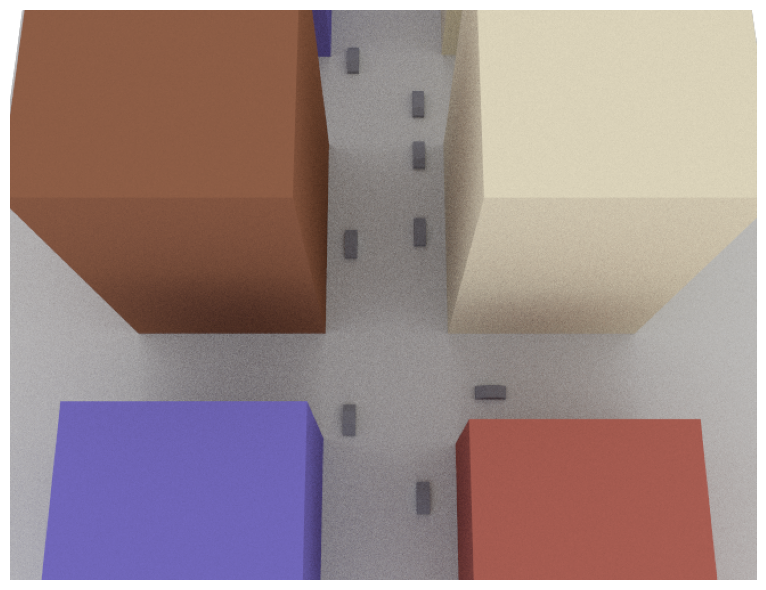

In [5]:
# Move the car 10m along the y-axis
car_2.position += [0, 10, 0]

# And rotate it by 90 degree around the z-axis
car_2.orientation = [np.pi/2, 0, 0]

if no_preview:
    scene.render(camera=cam);
else:
    scene.preview();

Em seguida, vamos visualizar mapas de cobertura para diferentes posições dos carros na cena, considerando que um dos carros esteja equipado com uma antena transmissora:

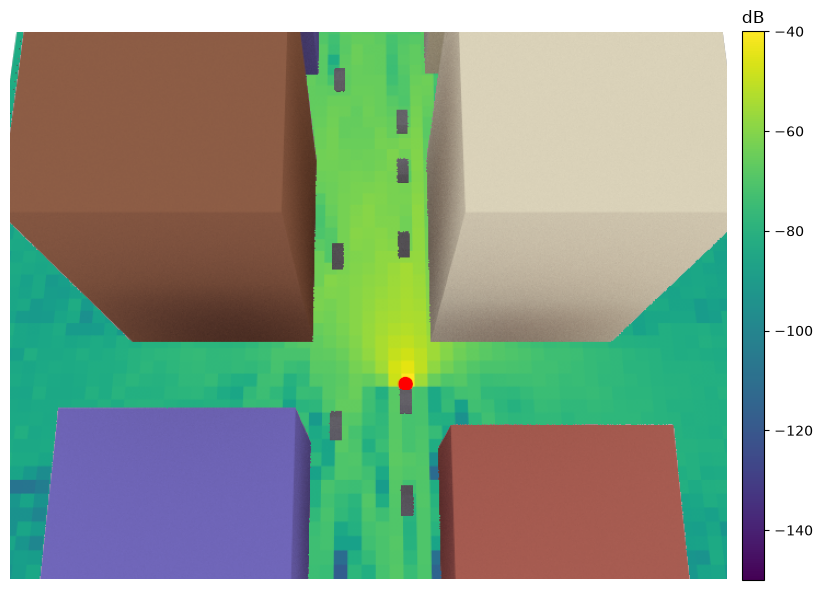

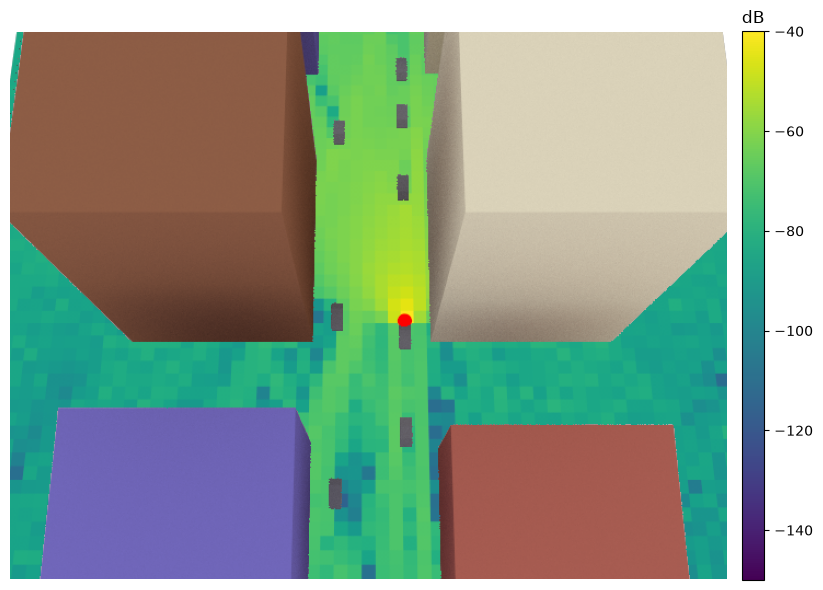

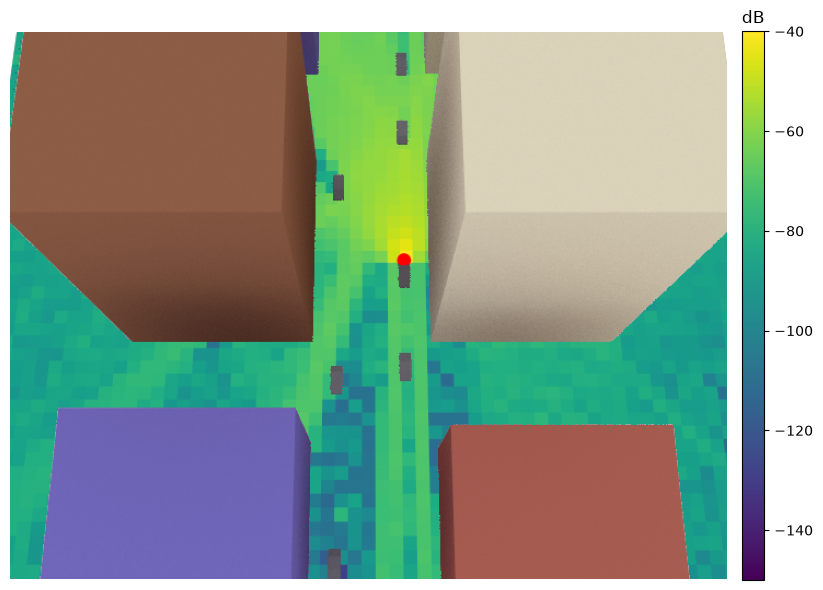

In [6]:
scene = load_scene(sionna.rt.scene.simple_street_canyon_with_cars,
                   merge_shapes=False)
cam =  Camera(position=[50,0,130], look_at=[10,0,0])

# Configure a transmitter that is located at the front of "car_2"
scene.add(Transmitter("tx", position=[22.7, 5.6, 0.75], orientation=[np.pi,0,0]))
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="tr38901", polarization="V")
scene.rx_array = scene.tx_array

# Create radio map solver
rm_solver = RadioMapSolver()

# Move cars along straight lines for a couple of steps
displacement_vec = [10, 0, 0]
num_displacements = 2
for _ in range(num_displacements+1):

    # Compute and render a coverage map at 0.5m above the ground
    rm = rm_solver(scene=scene,
                   samples_per_tx=20**6,
                   refraction=True,
                   max_depth=10,
                   center=[0,0,0.5],
                   orientation=[0,0,0],
                   size=[186,121],
                   cell_size=[2,2])
    scene.render(camera=cam, radio_map=rm,
                 num_samples=512, rm_show_color_bar=True,
                 rm_vmax=-40, rm_vmin=-150)

    # Move TX to next position
    scene.get("tx").position -= displacement_vec

    # Move cars driving in -x direction
    for j in range(1,6):
        scene.get(f"car_{j}").position -= displacement_vec

    # Move cars driving in x direction
    for j in range(6,9):
        scene.get(f"car_{j}").position += displacement_vec

## Evolução Temporal de Canais através do Efeito Doppler

Na seção anterior, vimos como a posição e a orientação dos objetos em uma cena podem ser modificadas. No entanto, se quisermos modelar a evolução dos canais ao longo de intervalos de tempo muito curtos, essa abordagem se torna impraticável.

Uma alternativa consiste em atribuir a todos os objetos em movimento um vetor de velocidade $\mathbf{v}_i\in\mathbb{R}^3$, a partir do qual podem ser calculados os deslocamentos Doppler para cada caminho de propagação.

Vamos agora carregar uma cena simples com um único refletor e modificar sua velocidade.

In [7]:
# Load scene with a single reflector
scene = load_scene(sionna.rt.scene.simple_reflector,
                   merge_shapes=False)
# Inspect the velocity of this object
print("Velocity vector: ", scene.get("reflector").velocity.numpy()[:,0])

# Update velocity vector
scene.get("reflector").velocity = [0, 0, -20]
print("Velocity vector after update: ", scene.get("reflector").velocity.numpy()[:,0])

Velocity vector:  [0. 0. 0.]
Velocity vector after update:  [  0.   0. -20.]


Em seguida, vamos adicionar um transmissor e um receptor para a cena e calcula os paths:

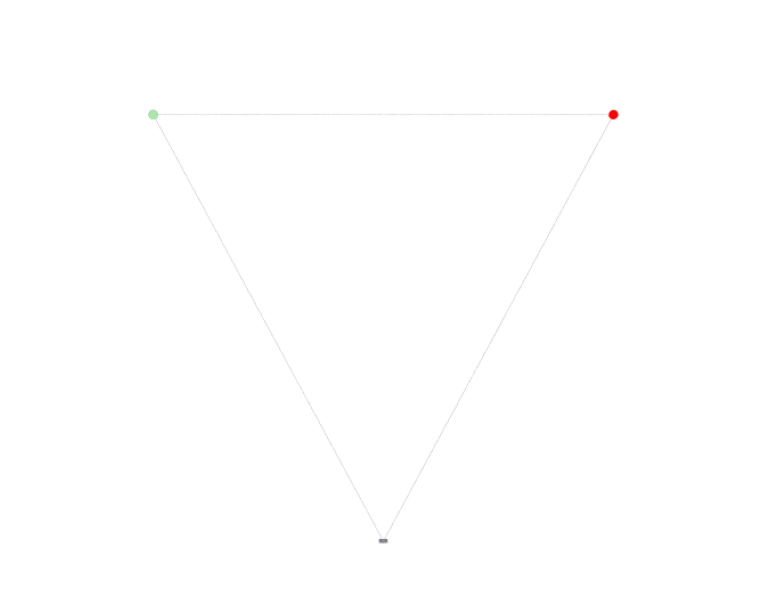

In [8]:
# Configure arrays for all transmitters and receivers in the scene
scene.tx_array = PlanarArray(num_rows=1,num_cols=1,pattern="iso", polarization="V")
scene.rx_array = scene.tx_array

# Add a transmitter and a receiver
scene.add(Transmitter("tx", [-25,0.1,50]))
scene.add(Receiver("rx",    [ 25,0.1,50]))

# Compute paths
p_solver = PathSolver()
paths = p_solver(scene=scene, max_depth=1)

# Visualize the scene and propagation paths
if no_preview:
    cam = Camera(position=[0, 100, 50], look_at=[0,0,30])
    scene.render(camera=cam, paths=paths);
else:
    scene.preview(paths=paths)

Cada caminho possui uma propriedade `Paths.doppler`, que corresponde ao deslocamento Doppler agregado devido ao movimento dos objetos que ele intercepta, bem como às velocidades do transmissor e do receptor.

In [9]:
print("Path interaction (0=LoS, 1=Specular reflection): ", paths.interactions.numpy())
print("Doppler shifts (Hz): ", paths.doppler.numpy())

Path interaction (0=LoS, 1=Specular reflection):  [[[[0 1]]]]
Doppler shifts (Hz):  [[[   0.      -417.68835]]]


### Exemplo: Espectro Delay-Doppler

Agora usaremos o efeito Doppler para calcular uma resposta ao impulso do canal que varia com o tempo e estimar seu espectro Delay-Doppler.

Para isso, assumimos que podemos observar 1024 símbolos consecutivos de um sistema OFDM com 1024 subportadoras, considerando um espaçamento entre subportadoras de 30 kHz. Isso definirá as seguintes resoluções nos domínios do atraso e do Doppler:

In [10]:
num_ofdm_symbols = 1024
num_subcarriers = 1024
subcarrier_spacing = 30e3

ofdm_symbol_duration = 1/subcarrier_spacing
delay_resolution = ofdm_symbol_duration/num_subcarriers
doppler_resolution = subcarrier_spacing/num_ofdm_symbols

print("Delay   resolution (ns): ", int(delay_resolution/1e-9))
print("Doppler resolution (Hz): ", int(doppler_resolution))

Delay   resolution (ns):  32
Doppler resolution (Hz):  29


Além do movimento do refletor, vamos considerar também que o transmissor está se movendo.

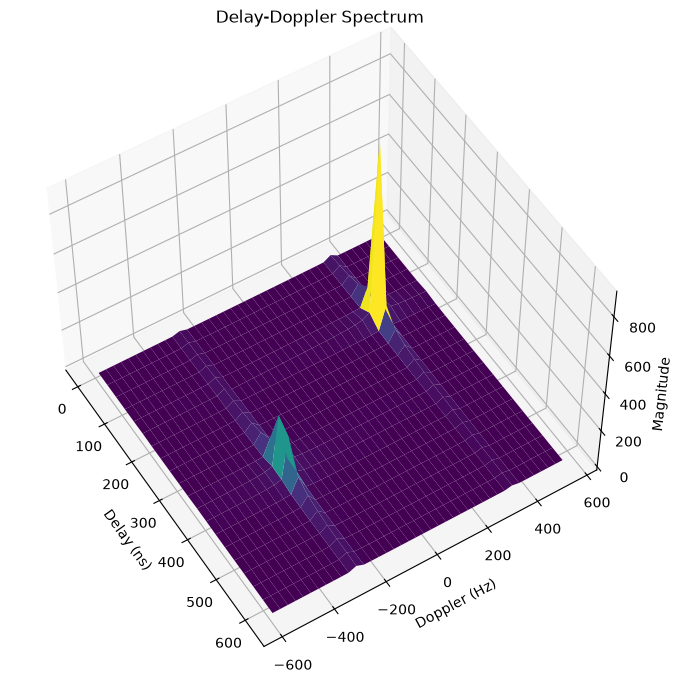

In [11]:
# Set TX velocity
tx_velocity = [30, 0, 0]
scene.get("tx").velocity = tx_velocity

# Recompute the paths
paths = p_solver(scene=scene, max_depth=1, refraction=False)

# Compute channel frequency response with time evolution
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

h = paths.cfr(frequencies=frequencies,
              sampling_frequency=1/ofdm_symbol_duration,
              num_time_steps=num_ofdm_symbols,
              normalize_delays=False, normalize=True, out_type="numpy")


### Compute the Delay-Doppler spectrum

# Squeeze useless dimensions
# [num_time_steps, fft_size]
h = np.squeeze(h)

# Apply an FFTshift to bring subcarriers in the
# correct order for an IFFT
h = np.fft.fftshift(h, axes=1)

# Apply IFFT to subcarrier dimension to
# convert frequency to delay domain
h_delay = np.fft.ifft(h, axis=1, norm="ortho")

# Apply FFT to time-step dimension to
# convert time to Doppler domain
h_delay_doppler = np.fft.fft(h_delay, axis=0, norm="ortho")

# Apply FFTShift to bring Doppler dimension in the correct
# order for visualization
h_delay_doppler = np.fft.fftshift(h_delay_doppler, axes=0)

# Compute meshgrid for visualization of the Delay-Doppler spectrum
doppler_bins = np.arange(-num_ofdm_symbols/2*doppler_resolution,
                          num_ofdm_symbols/2*doppler_resolution,
                         doppler_resolution)

delay_bins = np.arange(0,
                       num_subcarriers*delay_resolution,
                       delay_resolution) / 1e-9

x, y = np.meshgrid(delay_bins, doppler_bins)

# Visualize Delay-Doppler spectrum
fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

# We only visualize the relevant part of the spectrum
offset = 20
x_start = int(num_subcarriers/2)-offset
x_end = int(num_subcarriers/2)+offset
y_start = 0
y_end = offset
x_grid = x[x_start:x_end,y_start:y_end]
y_grid = y[x_start:x_end,y_start:y_end]
z_grid = np.abs(h_delay_doppler[x_start:x_end,y_start:y_end])

surf = ax.plot_surface(x_grid,
                       y_grid,
                       z_grid,
                       cmap='viridis', edgecolor='none')

ax.set_xlabel('Delay (ns)')
ax.set_ylabel('Doppler (Hz)')
ax.set_zlabel('Magnitude');
ax.zaxis.labelpad=2
ax.view_init(elev=53, azim=-32)
ax.set_title("Delay-Doppler Spectrum");

Como esperado, podemos observar dois picos no espectro Delay-Doppler acima. O primeiro ocorre em um atraso de aproximadamente 160 ns, e o segundo em um atraso de aproximadamente 370 ns. Os respectivos deslocamentos Doppler são de aproximadamente 350 Hz e −260 Hz.

Os deslocamentos Doppler exatos, calculados com base na equação apresentada nas [Informações básicas](#Background-Information), devem coincidir com os picos observados no espectro Delay-Doppler:

In [12]:
print("Delay - LoS Path (ns) :", paths.tau[0,0,0]/1e-9)
print("Doppler - LoS Path (Hz) :", paths.doppler[0,0,0])

print("Delay - Reflected Path (ns) :", paths.tau[0,0,1].numpy()/1e-9)
print("Doppler - Reflected Path (Hz) :", paths.doppler[0,0,1])

Delay - LoS Path (ns) : 166.782
Doppler - LoS Path (Hz) : 350.242
Delay - Reflected Path (ns) : 372.93597
Doppler - Reflected Path (Hz) : -261.056


## Resumo

Discutimos duas maneiras diferentes de simular a mobilidade no Sionna RT. É possível mover os objetos em uma cena e recalcular os caminhos de propagação ou calcular sinteticamente a evolução temporal dos canais com base nos deslocamentos Doppler obtidos a partir dos vetores de velocidade dos objetos da cena.

A primeira abordagem possui um alto custo computacional, mas é precisa, enquanto a segunda é muito mais rápida, porém só é precisa durante intervalos de tempo curtos, nos quais os objetos da cena tenham se deslocado por distâncias muito pequenas. A precisão também depende fortemente do cenário.

As duas abordagens podem ser combinadas para simular a mobilidade ao longo de períodos de tempo mais longos.

Esperamos que você tenha gostado de nossa exploração da simulação de mobilidade com o Sionna RT. Você também pode explorar nossos outros [tutoriais](https://nvlabs.github.io/sionna/rt/tutorials.html).